### Importing Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns             # optional, useful for EDA plots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Defining Performance Metrics

In [2]:
# Metrics
def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def r2(y_true, y_pred):
    return r2_score(y_true, y_pred)

### Loading dataset

In [3]:
# ===== Step 1: Load dataset & quick EDA =====
FNAME = "mobile_price.csv"   # change if necessary
TARGET_COL = "Price"

if not os.path.exists(FNAME):
    raise FileNotFoundError(f"Put your dataset CSV in the working directory and name it '{FNAME}' or change FNAME in the cell.")

df = pd.read_csv(FNAME)
print("Shape:", df.shape)
print("\nColumns and types:\n", df.dtypes)
print("\nFirst 5 rows:")
display(df.head())

Shape: (807, 8)

Columns and types:
 Ratings          float64
RAM              float64
ROM              float64
Mobile_Size      float64
Primary_Cam        int64
Selfi_Cam        float64
Battery_Power      int64
Price              int64
dtype: object

First 5 rows:


,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
0,4.3,4.0,128.0,6.00,48,13.0,4000,24999
1,3.4,6.0,64.0,4.50,48,12.0,4000,15999
2,4.3,4.0,4.0,4.50,64,16.0,4000,15000
3,4.4,6.0,64.0,6.40,48,15.0,3800,18999
4,4.5,6.0,128.0,6.18,35,15.0,3800,18999


### Handling Missing Values and displaying basic statistics

In [4]:
# Missing values
print("\nMissing values per column:")
print(df.isna().sum(),'\n')

# Basic statistics
print("Basic Statistics:")
display(df.describe().T)


Missing values per column:
Ratings          0
RAM              0
ROM              0
Mobile_Size      0
Primary_Cam      0
Selfi_Cam        0
Battery_Power    0
Price            0
dtype: int64 

Basic Statistics:


,count,mean,std,min,25%,50%,75%,max
Ratings,807.0,4.112639,0.367830,2.8,3.9,4.10,4.4,4.8
RAM,807.0,5.941760,2.056359,0.0,6.0,6.00,6.0,12.0
ROM,807.0,64.390335,53.868626,2.0,32.0,32.00,64.0,256.0
Mobile_Size,807.0,5.620660,3.957409,2.0,4.5,4.77,6.3,44.0
Primary_Cam,807.0,47.821561,11.155916,5.0,48.0,48.00,48.0,64.0
Selfi_Cam,807.0,8.868649,4.547254,0.0,8.0,8.00,12.0,23.0
Battery_Power,807.0,3278.859975,937.628801,1020.0,3000.0,3000.00,3800.0,6000.0
Price,807.0,14269.167286,23092.739983,479.0,984.0,1699.00,18994.5,153000.0


### Plotting histogram of target feature

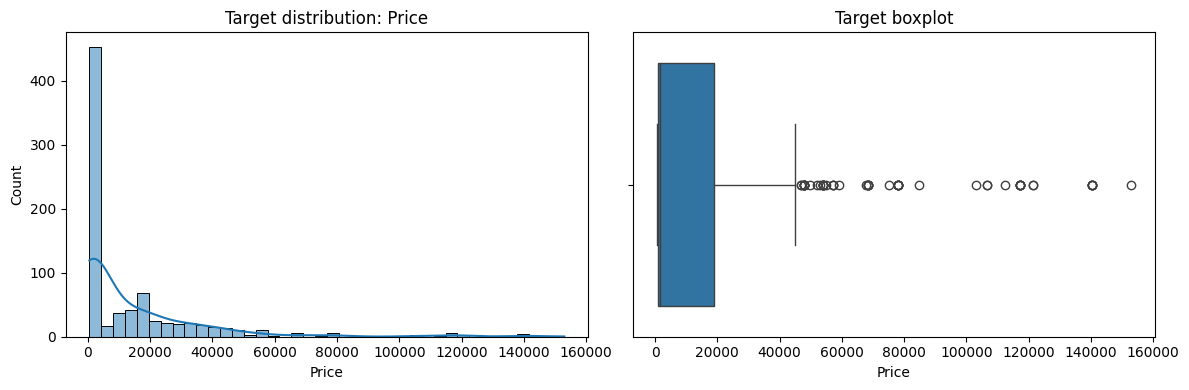

In [5]:
# Plot distributions for numeric features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL in num_cols:
    num_cols.remove(TARGET_COL)

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
sns.histplot(df[TARGET_COL], kde=True).set_title("Target distribution: " + TARGET_COL)
plt.subplot(1,2,2)
sns.boxplot(x=df[TARGET_COL]).set_title("Target boxplot")
plt.tight_layout()

### Plotting correlation map

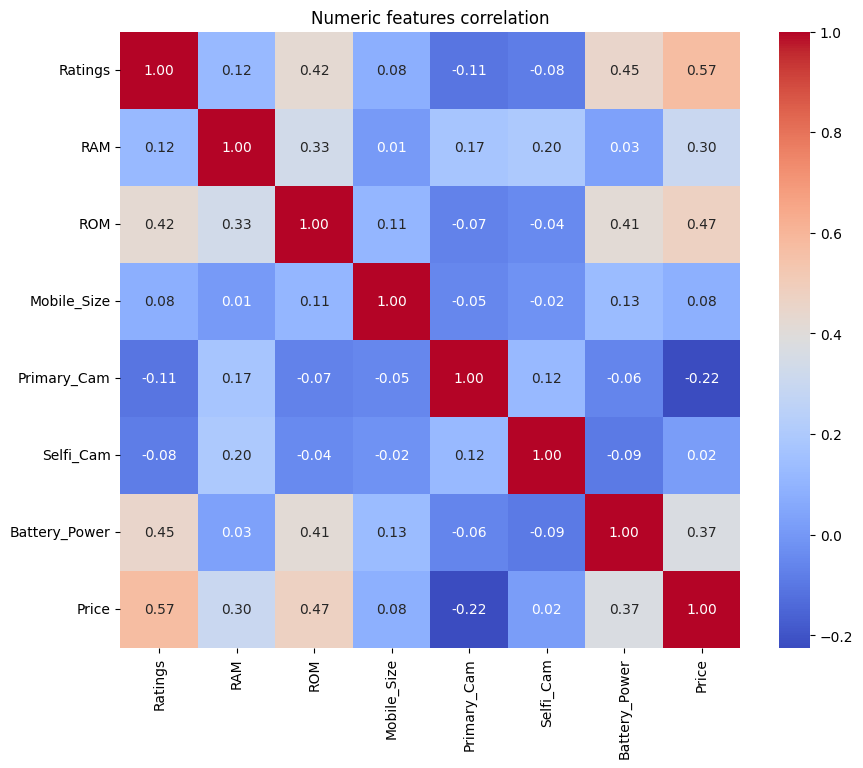

In [6]:
# Correlation heatmap (only numeric features)
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=False)
plt.title("Numeric features correlation")
plt.show()

### Plotting all features with target

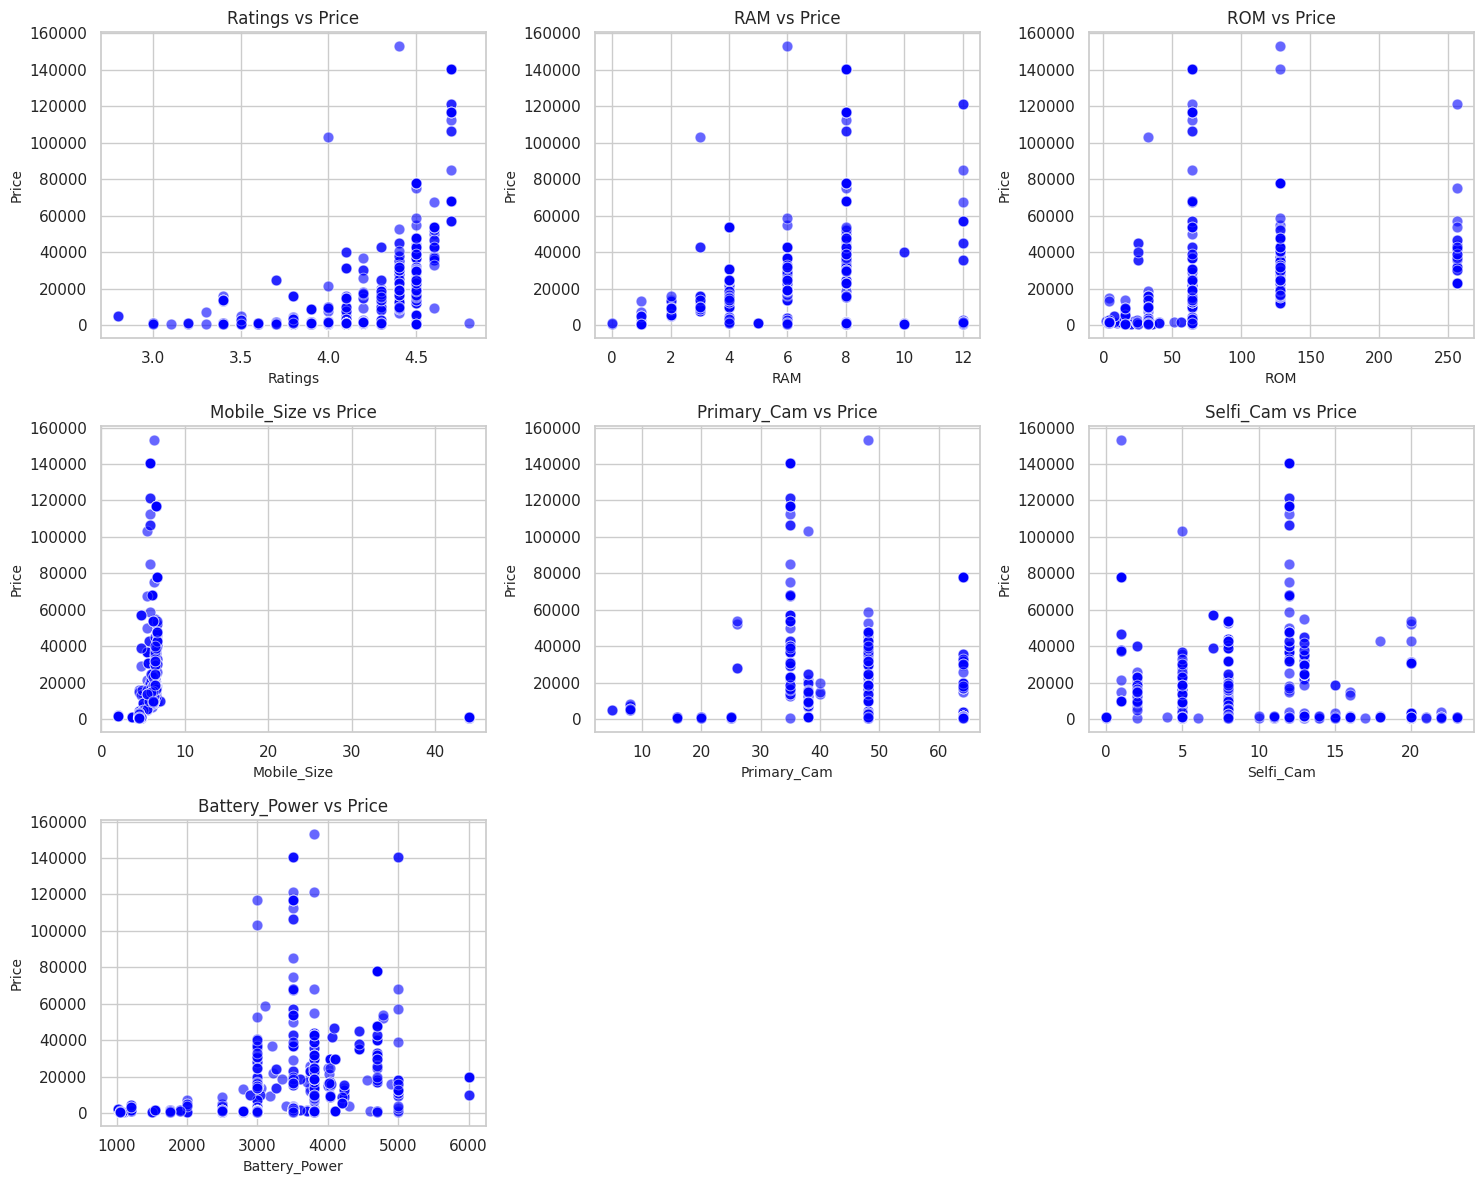

In [7]:
features = ["Ratings", "RAM", "ROM", "Mobile_Size", 
            "Primary_Cam", "Selfi_Cam", "Battery_Power"]

# 3. Set style
sns.set(style="whitegrid", palette="muted")

# 4. Plot all scatterplots with regression lines
plt.figure(figsize=(15, 12))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=df[feature], y=df["Price"], s=60, color="blue", alpha=0.6)
    #sns.regplot(x=df[feature], y=df["Price"], scatter=False, color="red")
    plt.xlabel(feature, fontsize=10)
    plt.ylabel("Price", fontsize=10)
    plt.title(f"{feature} vs Price", fontsize=12)

plt.tight_layout()
plt.show()

### Splitting final X and y

In [8]:
df = df.dropna(subset=[TARGET_COL])

X_df = df.drop(columns=[TARGET_COL]).copy()
y_df = df[[TARGET_COL]].copy()   # keep as DataFrame for shape clarity

print("Final feature count:", X_df.shape[1])
print("Examples of features:", X_df.columns.tolist()[:10])


Final feature count: 7
Examples of features: ['Ratings', 'RAM', 'ROM', 'Mobile_Size', 'Primary_Cam', 'Selfi_Cam', 'Battery_Power']


### Doing train/test split

In [9]:
# ===== Step 3: Train/test split and matrix construction =====
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(
    X_df, y_df, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Convert to numpy arrays
X_train = X_train_df.values.astype(float)    # shape: (n_train, d)
X_test  = X_test_df.values.astype(float)     # shape: (n_test, d)
y_train = y_train_df.values.astype(float)    # shape: (n_train, 1)
y_test  = y_test_df.values.astype(float)     # shape: (n_test, 1)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)


X_train shape: (645, 7)
X_test  shape: (162, 7)
y_train shape: (645, 1)
y_test  shape: (162, 1)


### Adiition of bias(intercept)

In [11]:
def add_bias(X):
    """Add a column of ones for the intercept term"""
    return np.hstack([np.ones((X.shape[0],1)), X])

X_train_b = add_bias(X_train)
X_test_b  = add_bias(X_test)

### Finding theta and intercept value using closed form solution

In [10]:
def gradient_descent(X_b, y, alpha=1e-3, epochs=5000, l2=0.0, regularize_bias=False, tol=None, verbose=False):
    """
    Batch Gradient Descent for Linear Regression with optional L2 regularization.
    Returns: (theta, history)
    - theta: (d+1, 1) parameter vector including bias
    - history: dictionary containing loss per epoch
    """
    n, d_plus_1 = X_b.shape
    theta = np.zeros((d_plus_1, 1), dtype=float)
    history = {'loss': []}
    
    for epoch in range(epochs):
        preds = X_b @ theta
        error = preds - y
        loss = float((error**2).mean())
        history['loss'].append(loss)
        
        grad = (2.0 / n) * (X_b.T @ error)
        
        # L2 regularization
        if l2 > 0.0:
            reg = 2.0 * l2 * theta
            if not regularize_bias:
                reg[0,0] = 0.0
            grad += reg
        
        theta = theta - alpha * grad
        
        # optional early stopping
        if tol is not None and epoch > 0 and abs(history['loss'][-2] - loss) < tol:
            if verbose:
                print(f"Converged at epoch {epoch}")
            break
        
        if verbose and (epoch % (epochs//5 + 1) == 0):
            print(f"Epoch {epoch}/{epochs}, loss={loss:.4f}")
    
    return theta, history


### Predicting without standarization and regularization

In [19]:
X_train_b = add_bias(X_train)
X_test_b  = add_bias(X_test)

# Very small learning rate needed due to large feature scales
alpha = 1e-8
epochs = 5000

theta_gd_raw, hist_gd_raw = gradient_descent(
    X_train_b, y_train, alpha=alpha, epochs=epochs, l2=0.0, verbose=True
)

y_pred_test_raw  = X_test_b @ theta_gd_raw
y_pred_train_raw = X_train_b @ theta_gd_raw

print("Test RMSE:", rmse(y_test, y_pred_test_raw))
print("Test R2:", r2(y_test, y_pred_test_raw))


Epoch 0/5000, loss=764434363.9395
Epoch 1001/5000, loss=495980326.2819
Epoch 2002/5000, loss=489240337.1649
Epoch 3003/5000, loss=483097269.7896
Epoch 4004/5000, loss=477495686.5116
Test RMSE: 18720.797380258216
Test R2: 0.17013081288846654


### Predicted vs Actual Plot

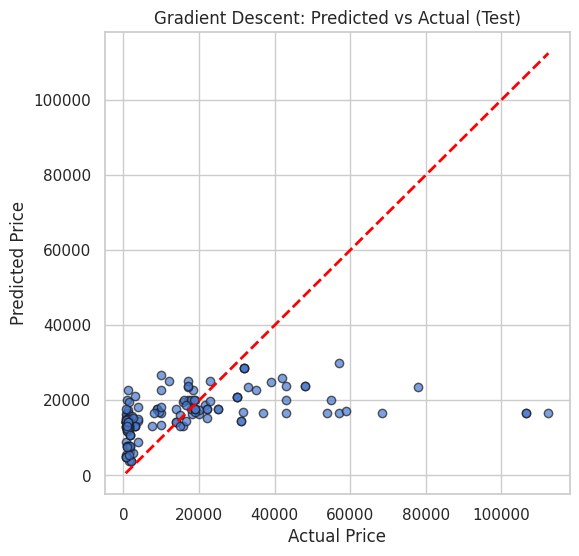

In [22]:
# Predicted vs Actual (Test set)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test_raw, alpha=0.7, edgecolor='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2)  # ideal line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Gradient Descent: Predicted vs Actual (Test)")
plt.grid(True)
plt.show()


### Predicting with standarization and without regularization

In [28]:
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Add bias term
X_train_b_s = add_bias(X_train_scaled)
X_test_b_s  = add_bias(X_test_scaled)

# Hyperparameters
alpha = 1e-2   # larger learning rate works for standardized features
epochs = 5000

# Fit gradient descent
theta_gd_std, hist_gd_std = gradient_descent(
    X_train_b_s, y_train, alpha=alpha, epochs=epochs, l2=0.0, verbose=True
)

# Predictions
y_pred_train_std = X_train_b_s @ theta_gd_std
y_pred_test_std  = X_test_b_s @ theta_gd_std

# Performance
print("Standardized, No L2 -> Test RMSE:", rmse(y_test, y_pred_test_std))
print("Standardized, No L2 -> Test R2:", r2(y_test, y_pred_test_std))


Epoch 0/5000, loss=764434363.9395
Epoch 1001/5000, loss=298488983.8195
Epoch 2002/5000, loss=298488983.7835
Epoch 3003/5000, loss=298488983.7835
Epoch 4004/5000, loss=298488983.7835
Standardized, No L2 -> Test RMSE: 15471.187977381838
Standardized, No L2 -> Test R2: 0.43322813972091834


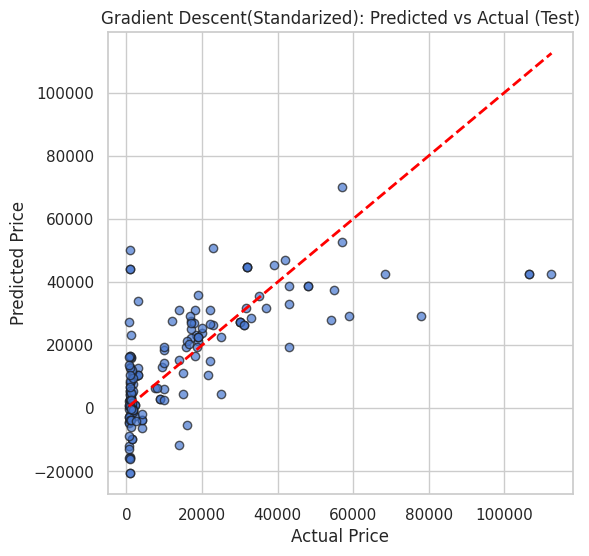

In [29]:
# Predicted vs Actual (Test set)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test_std, alpha=0.7, edgecolor='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2)  # ideal line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Gradient Descent(Standarized): Predicted vs Actual (Test)")
plt.grid(True)
plt.show()


### L2 Regularization without Standardization

In [53]:
X_train_b = add_bias(X_train)
X_test_b  = add_bias(X_test)

# Very small learning rate needed due to large feature scales
alpha = 1e-8
epochs = 5000

theta_gd_raw, hist_gd_raw = gradient_descent(
    X_train_b, y_train, alpha=alpha, epochs=epochs, l2=1, verbose=True
)

y_pred_test_raw  = X_test_b @ theta_gd_raw
y_pred_train_raw = X_train_b @ theta_gd_raw

print("No Standardization, No L2 -> Test RMSE:", rmse(y_test, y_pred_test_raw))
print("No Standardization, No L2 -> Test R2:", r2(y_test, y_pred_test_raw))


Epoch 0/5000, loss=764434363.9395
Epoch 1001/5000, loss=495980397.9764
Epoch 2002/5000, loss=489240602.7259
Epoch 3003/5000, loss=483097823.1466
Epoch 4004/5000, loss=477496597.8884
No Standardization, No L2 -> Test RMSE: 18720.828385450277
No Standardization, No L2 -> Test R2: 0.17012806404456682


### L2 Regularization with Standardization

In [64]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
l2_lambda=10
# Add bias
X_train_b_s = add_bias(X_train_scaled)
X_test_b_s  = add_bias(X_test_scaled)

theta_gd_std_l2, hist_gd_std_l2 = gradient_descent(
    X_train_b_s, y_train, alpha=1e-2, epochs=5000, l2=1, verbose=True
)

y_pred_test_std_l2  = X_test_b_s @ theta_gd_std_l2
y_pred_train_std_l2 = X_train_b_s @ theta_gd_std_l2

print(f"With Standardization, L2 λ={l2_lambda} -> Test RMSE:", rmse(y_test, y_pred_test_std_l2))
print(f"With Standardization, L2 λ={l2_lambda} -> Test R2:", r2(y_test, y_pred_test_std_l2))


Epoch 0/5000, loss=764434363.9395
Epoch 1001/5000, loss=338611141.8045
Epoch 2002/5000, loss=338611141.8045
Epoch 3003/5000, loss=338611141.8045
Epoch 4004/5000, loss=338611141.8045
With Standardization, L2 λ=10 -> Test RMSE: 15459.349791023782
With Standardization, L2 λ=10 -> Test R2: 0.43409516866783915


### Lambda vs R2 score plot

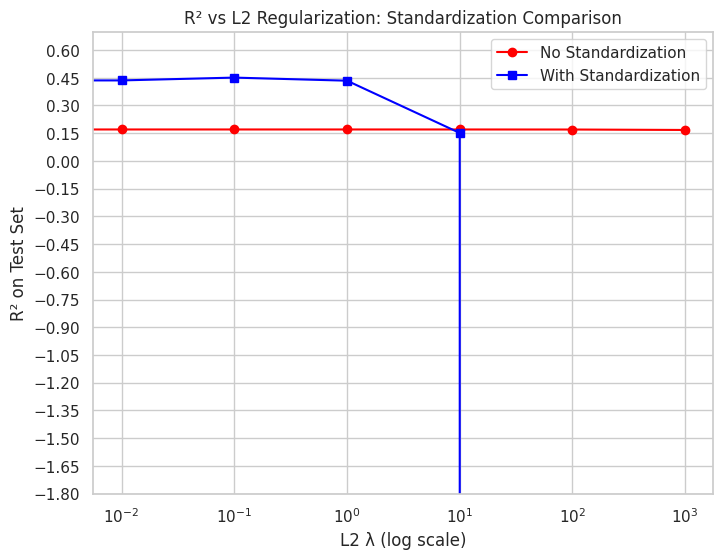

In [79]:

lambda_vals_no_std = [0, 0.01, 0.1, 1, 10, 100, 1000]
lambda_vals_std    = [0, 0.01, 0.1, 1, 10, 100]

# -------------------------------
# Without Standardization
# -------------------------------
X_train_b = add_bias(X_train)
X_test_b  = add_bias(X_test)

r2_no_std = []
for l in lambda_vals_no_std:
    theta, _ = gradient_descent(
        X_train_b, y_train, alpha=1e-8, epochs=5000, l2=l
    )
    y_pred = X_test_b @ theta
    r2_no_std.append(r2(y_test, y_pred))

# -------------------------------
# With Standardization
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_b_s = add_bias(X_train_scaled)
X_test_b_s  = add_bias(X_test_scaled)

r2_std = []
for l in lambda_vals_std:
    theta, _ = gradient_descent(
        X_train_b_s, y_train, alpha=1e-2, epochs=5000, l2=l
    )
    y_pred = X_test_b_s @ theta
    r2_std.append(r2(y_test, y_pred))

# -------------------------------
# Combined Plot
# -------------------------------
plt.figure(figsize=(8,6))
plt.plot(lambda_vals_no_std, r2_no_std, marker='o', color='red', label="No Standardization")
plt.plot(lambda_vals_std, r2_std, marker='s', color='blue', label="With Standardization")
plt.xscale('log')
plt.xlabel("L2 λ (log scale)")
plt.ylabel("R² on Test Set")
plt.title("R² vs L2 Regularization: Standardization Comparison")
plt.ylim(-1.8, 0.7)
plt.yticks(np.arange(-1.8, 0.71, 0.15))
plt.grid(True)
plt.legend()
plt.show()


### Predicted vs actual plot for both with and without standardization

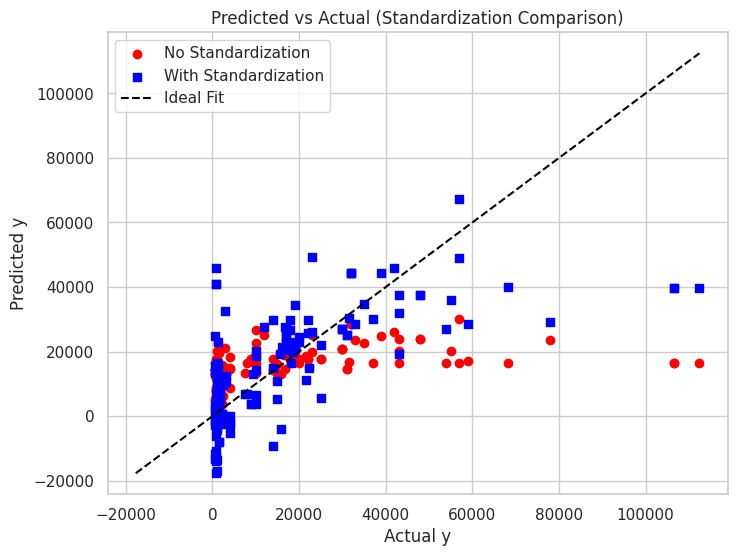

In [80]:
# -------------------------------
# Predictions without Standardization
# -------------------------------
X_train_b = add_bias(X_train)
X_test_b  = add_bias(X_test)

theta_no_std, _ = gradient_descent(
    X_train_b, y_train, alpha=1e-8, epochs=5000, l2=0.1  # example lambda
)
y_pred_no_std = X_test_b @ theta_no_std

# -------------------------------
# Predictions with Standardization
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_b_s = add_bias(X_train_scaled)
X_test_b_s  = add_bias(X_test_scaled)

theta_std, _ = gradient_descent(
    X_train_b_s, y_train, alpha=1e-2, epochs=5000, l2=0.1  # same lambda for comparison
)
y_pred_std = X_test_b_s @ theta_std

# -------------------------------
# Combined Predicted vs Actual Plot
# -------------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_no_std, color='red', marker='o', label='No Standardization')
plt.scatter(y_test, y_pred_std, color='blue', marker='s', label='With Standardization')

# Reference line y=x
min_val = min(y_test.min(), y_pred_no_std.min(), y_pred_std.min())
max_val = max(y_test.max(), y_pred_no_std.max(), y_pred_std.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Ideal Fit')

plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Predicted vs Actual (Standardization Comparison)")
plt.legend()
plt.grid(True)
plt.show()

### Predicted vs actual plot for different lambda values

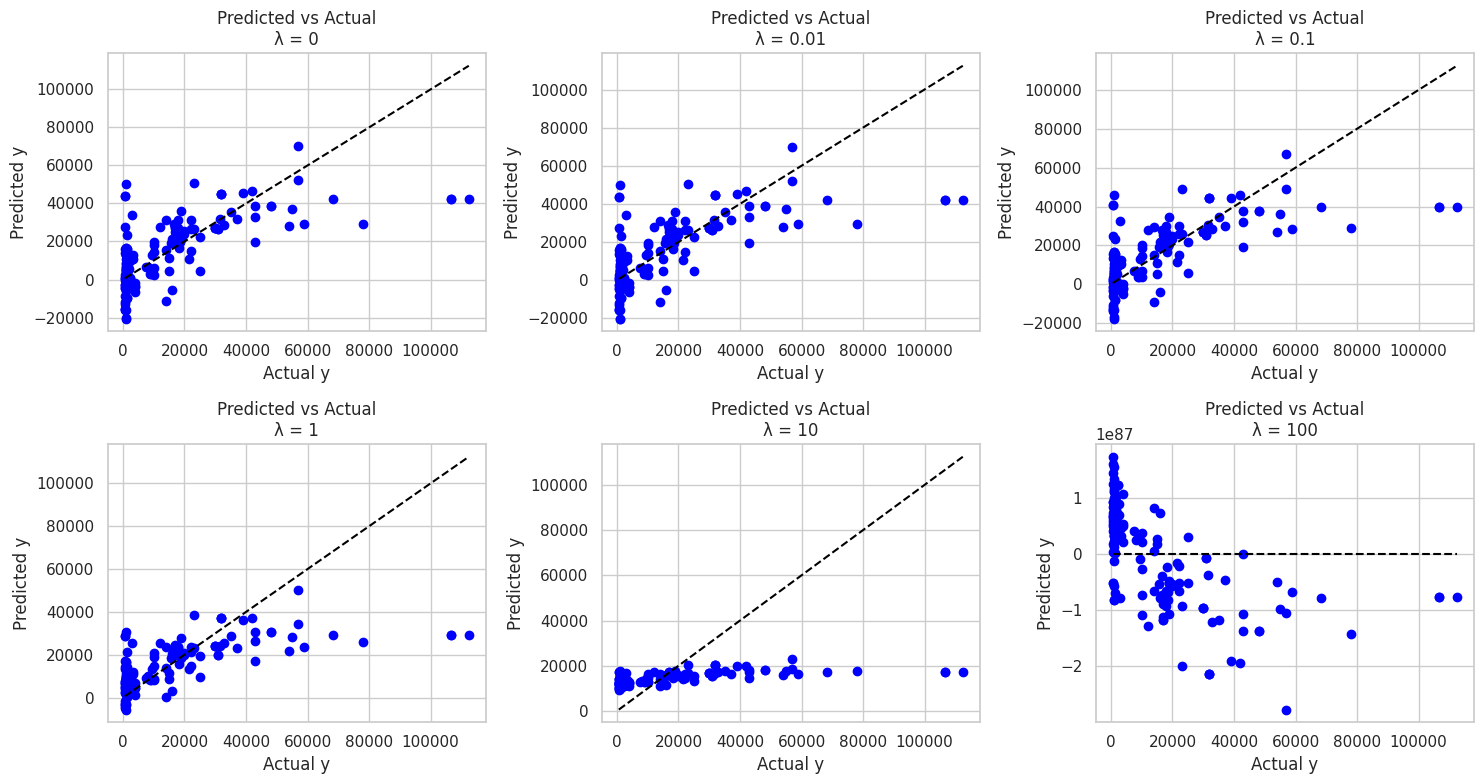

In [81]:
# Lambda values to test
lambda_vals = [0, 0.01, 0.1, 1, 10, 100]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_b_s = add_bias(X_train_scaled)
X_test_b_s  = add_bias(X_test_scaled)

# Create subplots
n = len(lambda_vals)
cols = 3
rows = (n + cols - 1) // cols  # ceil division
plt.figure(figsize=(5*cols, 4*rows))

for i, l in enumerate(lambda_vals):
    theta, _ = gradient_descent(
        X_train_b_s, y_train, alpha=1e-2, epochs=5000, l2=l
    )
    y_pred = X_test_b_s @ theta
    
    plt.subplot(rows, cols, i+1)
    plt.scatter(y_test, y_pred, color='blue', marker='o')
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='black', linestyle='--')
    plt.xlabel("Actual y")
    plt.ylabel("Predicted y")
    plt.title(f"Predicted vs Actual\nλ = {l}")
    plt.grid(True)

plt.tight_layout()
plt.show()


### Feature importance with l2 weights

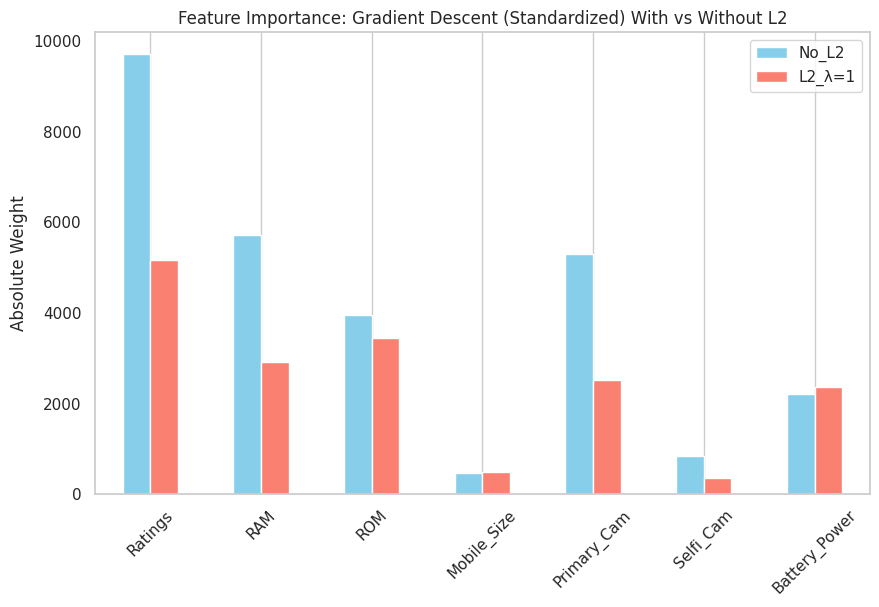

In [88]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Feature names
feature_names = ["Ratings", "RAM", "ROM", "Mobile_Size", "Primary_Cam", "Selfi_Cam", "Battery_Power"]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_b_s = add_bias(X_train_scaled)
X_test_b_s  = add_bias(X_test_scaled)

# Gradient Descent: No L2
theta_no_l2, _ = gradient_descent(
    X_train_b_s, y_train, alpha=1e-2, epochs=5000, l2=0
)

# Gradient Descent: With L2
l2_lambda = 100
theta_l2, _ = gradient_descent(
    X_train_b_s, y_train, alpha=1e-2, epochs=5000, l2=1
)

# Absolute weights (skip bias)
weights_no_l2 = np.abs(theta_no_l2[1:].flatten())
weights_l2    = np.abs(theta_l2[1:].flatten())

# Create DataFrame for plotting
feat_imp_df = pd.DataFrame({
    "No_L2": weights_no_l2,
    f"L2_λ=1": weights_l2
}, index=feature_names)

# Plot
feat_imp_df.plot(kind="bar", figsize=(10,6), color=["skyblue", "salmon"])
plt.ylabel("Absolute Weight")
plt.title("Feature Importance: Gradient Descent (Standardized) With vs Without L2")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()
